# §3 Monte Carlo on combined (unfiltered) (v11)

IID bootstrap (10,000 sims) on the combined unfiltered trade stream.
Plots: bootstrap equity paths, final PnL histogram, annualized Sharpe
histogram, max-drawdown histogram — one of each per sizing policy.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
while not (REPO / 'src').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from scripts.evaluation._top_perf_common import (
    STARTING_EQUITY, RISK_FRAC, POLICIES,
    apply_sizing, metrics_from_pnl, monte_carlo,
    load_setup,
    plot_indiv_equity, plot_indiv_dd,
    plot_combined_equity, plot_combined_dd,
    plot_ml2_indiv_equity, plot_ml2_indiv_dd,
    plot_ml2_combined_equity, plot_ml2_combined_dd,
    plot_mc_sims, plot_mc_pnl, plot_mc_sharpe, plot_mc_dd,
)

_ctx = load_setup(cost_per_contract_rt=0.0, top_strategies_path=REPO / 'evaluation' / 'top_strategies_v11.json')
bars            = _ctx['bars']
YEARS_SPAN      = _ctx['years_span']
strategies      = _ctx['strategies']
results_raw     = _ctx['results_raw']
combined_raw    = _ctx['combined_raw']
combos_ml2      = _ctx['combos_ml2']
s4_pnl_by_combo = _ctx['s4_pnl_by_combo']
ml2_portfolio   = _ctx['ml2_portfolio']


Top-K source: top_strategies_v11.json


Test partition: 514,563 bars  2024-10-22 05:08:00 -> 2026-04-08 20:20:00
Years span: 1.461  (used to annualize Sharpe)
Loaded 10 strategies.
Loaded results_raw from cache (10 combos).
Combined unfiltered trades: 14,717
Loaded combos_ml2 from cache (10 combos).


ML2 portfolio trade counts: {'fixed_dollars_500': 658, 'pct5_compound': 658}


In [2]:
rows = []
for policy in POLICIES:
    if combined_raw.empty:
        rows.append({'policy': policy, 'n_trades': 0}); continue
    pnl_base = combined_raw['actual_pnl'].to_numpy(dtype=float)
    risk_base = combined_raw['dollar_risk'].to_numpy(dtype=float)
    rows.append({'policy': policy,
                 **monte_carlo(pnl_base, risk_base, policy, YEARS_SPAN)})
mc_raw = pd.DataFrame(rows)
mc_raw

,policy,n_sims,n_trades,win_rate,wr_ci_95,dd_p50_pct,dd_p90_pct,dd_p95_pct,dd_p99_pct,dd_worst_pct,...,dd_p95_dollars,dd_p99_dollars,dd_worst_dollars,var_5pct_trade,cvar_5pct_trade,risk_of_ruin_prob,trades_per_year,sharpe_p50,sharpe_ci_95,sharpe_pos_prob
0,fixed_dollars_500,10000,14717,0.2442,"(0.2372, 0.2512)",30.66,55.0,66.13,90.99,174.85,...,6.079899e+04,7.551438e+04,1.176276e+05,-495.00,-4.950000e+02,0.1403,10073.2,3.1876,"(1.5952, 4.7692)",1.0000
1,pct5_compound,10000,14717,0.2442,"(0.2372, 0.2512)",100.00,100.0,100.00,100.00,100.00,...,5.619509e+10,1.513036e+13,2.398426e+18,-761485.16,-9.184449e+12,1.0000,10073.2,-0.3241,"(-1.9624, 1.2962)",0.3443


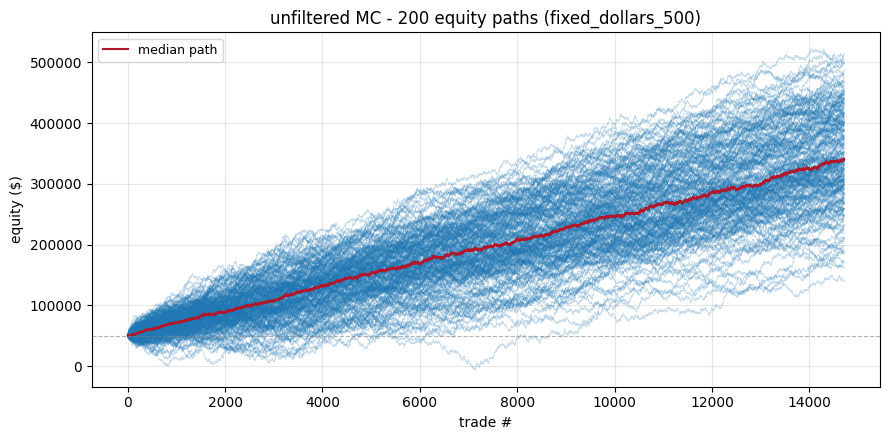

In [3]:
plot_mc_sims(combined_raw, 'fixed_dollars_500', 'unfiltered', YEARS_SPAN)

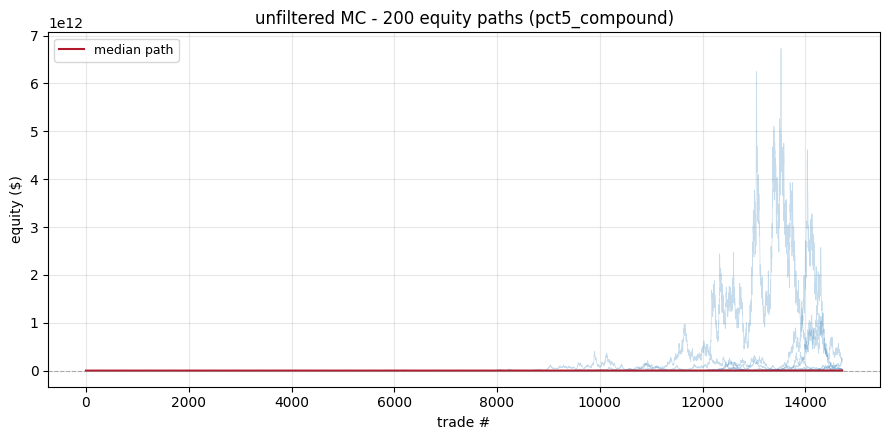

In [4]:
plot_mc_sims(combined_raw, 'pct5_compound', 'unfiltered', YEARS_SPAN)

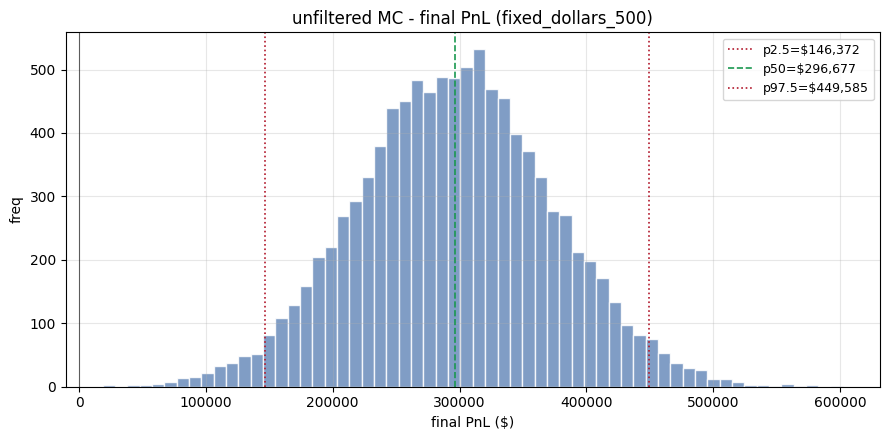

In [5]:
plot_mc_pnl(combined_raw, 'fixed_dollars_500', 'unfiltered', YEARS_SPAN)

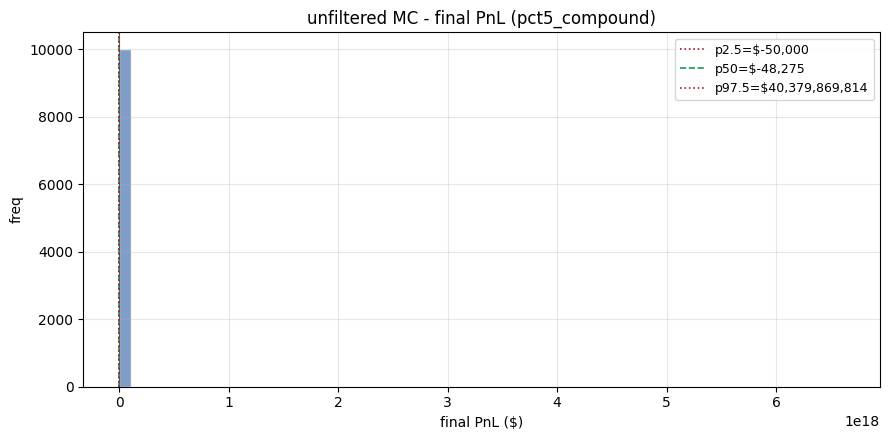

In [6]:
plot_mc_pnl(combined_raw, 'pct5_compound', 'unfiltered', YEARS_SPAN)

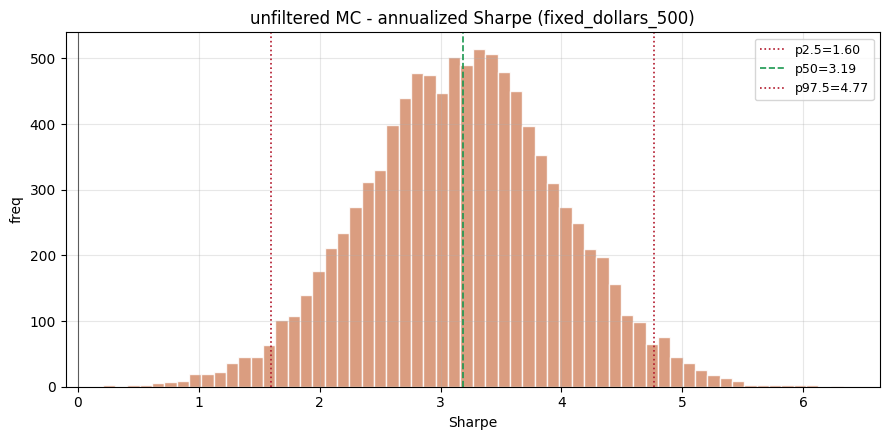

In [7]:
plot_mc_sharpe(combined_raw, 'fixed_dollars_500', 'unfiltered', YEARS_SPAN)

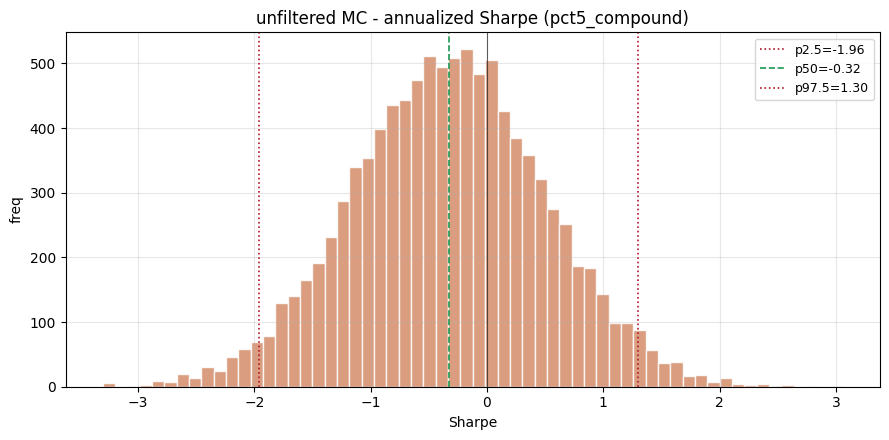

In [8]:
plot_mc_sharpe(combined_raw, 'pct5_compound', 'unfiltered', YEARS_SPAN)

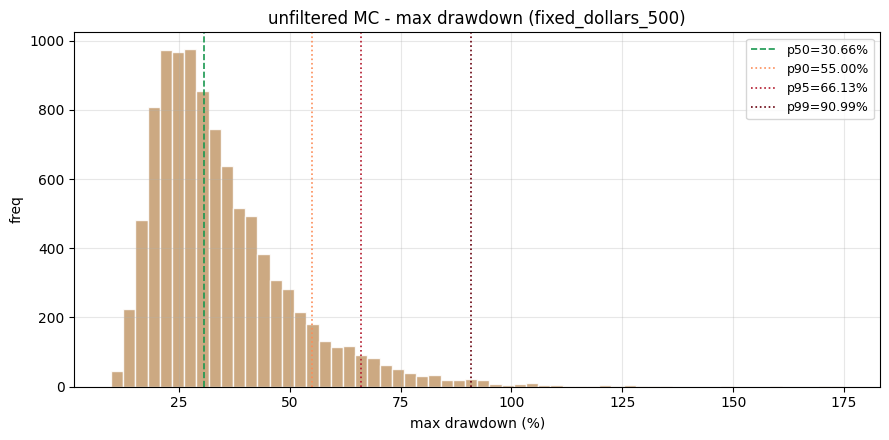

In [9]:
plot_mc_dd(combined_raw, 'fixed_dollars_500', 'unfiltered', YEARS_SPAN)

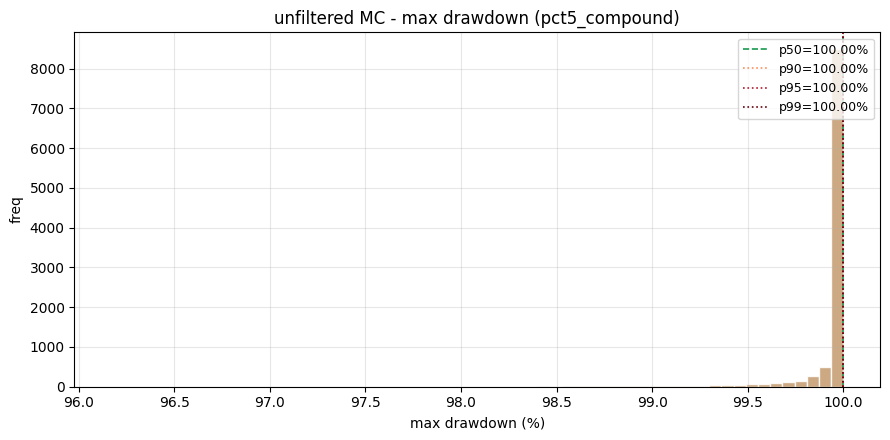

In [10]:
plot_mc_dd(combined_raw, 'pct5_compound', 'unfiltered', YEARS_SPAN)